In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df=pd.read_csv("./Data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [22]:
df.isnull().sum()   # no null values

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [24]:
(df==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

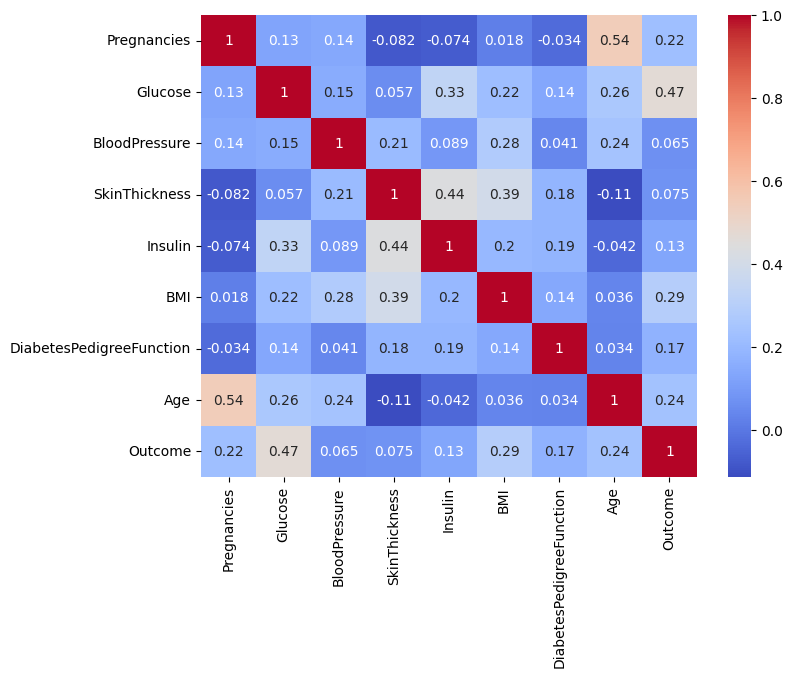

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()


In [48]:
X=df[["Glucose","BMI"]].values

y=df["Outcome"].values

In [49]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X = (X - X_mean) / X_std

In [50]:
print(X[:10])
print(y[:10])

[[ 0.84832379  0.20401277]
 [-1.12339636 -0.68442195]
 [ 1.94372388 -1.10325546]
 [-0.99820778 -0.49404308]
 [ 0.5040552   1.4097456 ]
 [-0.15318486 -0.81134119]
 [-1.34247638 -0.12597727]
 [-0.184482    0.41977549]
 [ 2.38188392 -0.18943689]
 [ 0.12848945 -4.06047387]]
[1 0 1 0 1 0 1 0 1 1]


In [51]:
## Defining Sigmoid Function

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [52]:
w=np.zeros(2)     # because we have do this here m=[m1,m2]  2 features--> 2 weights
c=0
lr=0.001
epochs=500
n=len(y)

print(" Initial Weights of both features:",w)
print(" Initial bias:",c)

 Initial Weights of both features: [0. 0.]
 Initial bias: 0


In [53]:
for i in range(epochs):
    z= X @ m + c
    y_pred=sigmoid(z)

    dw = (1/n) * (X.T @ (y_pred - y))      ## gradients = Xᵀ × error
    dc = (1/n) * np.sum(y_pred - y)

    w = w - lr*dw
    c=c-lr*dc

    if i% (epochs//10)==0:
        loss = (-1/n) * np.sum(
            y * np.log(y_pred + 1e-9) +
            (1 - y) * np.log(1 - y_pred + 1e-9)
        )

        print("epoch",i)
        print("loss",loss)
        print("m",m)
        print("c",c)
        print()

epoch 0
loss 0.6931471785599453
m [0. 0.]
c -0.00015104166666666665

epoch 50
loss 0.6920205005977864
m [0. 0.]
c -0.007655176585245463

epoch 100
loss 0.690921643403589
m [0. 0.]
c -0.01506608360169554

epoch 150
loss 0.6898499189000492
m [0. 0.]
c -0.022384924753285688

epoch 200
loss 0.6888046553636152
m [0. 0.]
c -0.029612849934844747

epoch 250
loss 0.6877851970953707
m [0. 0.]
c -0.036750996873029664

epoch 300
loss 0.686790904094397
m [0. 0.]
c -0.043800491109913214

epoch 350
loss 0.6858211517338791
m [0. 0.]
c -0.050762445995412506

epoch 400
loss 0.6848753304402344
m [0. 0.]
c -0.057637962688096074

epoch 450
loss 0.6839528453754973
m [0. 0.]
c -0.06442813016392333



In [57]:
z_final=X @ w + c
probabilities=sigmoid(z_final)

print(probabilities[:10])

y_pred_class=np.where(probabilities>=0.5,1,0)

print(y_pred_class[:10])
## ACCURACY
accuracy = np.mean(y_pred_class == y)
print(accuracy)

[0.50938897 0.43938468 0.51703731 0.44609548 0.5208342  0.46390554
 0.44298257 0.4844468  0.54503777 0.41582114]
[1 0 1 0 1 0 0 0 1 0]
0.7682291666666666
